In [1]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

os.makedirs('../plots', exist_ok=True)

In [2]:
results_path = "../results/optimization_results.pkl"

with open(results_path, 'rb') as f:
    d = pickle.load(f)

all_results       = d['all_results']
starts_n          = d['starts_n']
GT_LIFETIME_US    = d['GT_LIFETIME_US']
GT_VELOCITY_CM_US = d['GT_VELOCITY_CM_US']
N_STEPS           = d['N_STEPS']
N_TRIES           = d['N_TRIES']
NOISE_FRAC        = d['NOISE_FRAC']

LOSS_NAMES = list(all_results.keys())
OPT_NAMES  = list(next(iter(all_results.values())).keys())
OPT_COLORS = {'SGD': 'steelblue', 'Adam': 'darkorange', 'AdamW': 'forestgreen'}

print(f'Loaded: {results_path}')
print(f'  Loss types : {LOSS_NAMES}')
print(f'  Optimizers : {OPT_NAMES}')
print(f'  N_TRIES={N_TRIES}, N_STEPS={N_STEPS}, noise={NOISE_FRAC*100:.0f}%')
print(f'  GT: lifetime={GT_LIFETIME_US:.0f} μs, velocity={GT_VELOCITY_CM_US:.4f} cm/μs')

Loaded: ../results/optimization_results.pkl
  Loss types : ['Sobolev', 'MSE', 'L1']
  Optimizers : ['Adam', 'AdamW']
  N_TRIES=3, N_STEPS=200, noise=20%
  GT: lifetime=10000 μs, velocity=0.1600 cm/μs


## 2D Parameter Trajectories

One panel per loss function. Circles = starting point, squares = final point. Colour fades in as steps progress.

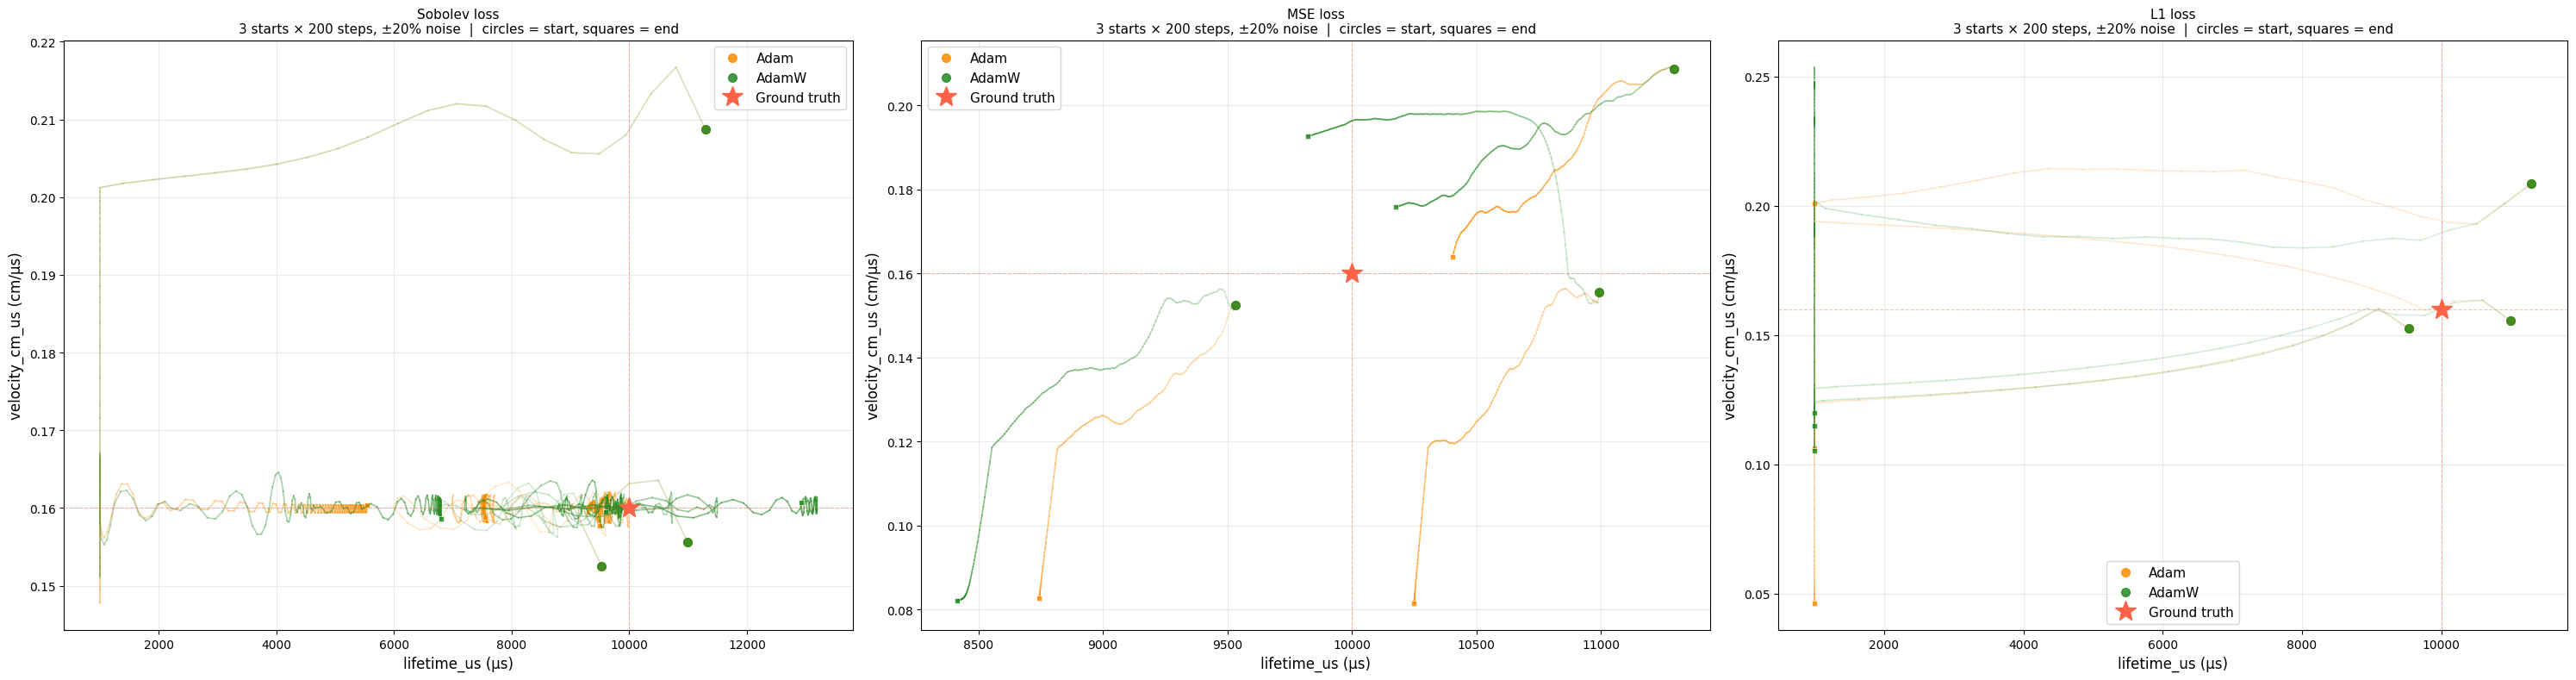

In [3]:
fig, axes = plt.subplots(1, len(LOSS_NAMES), figsize=(10 * len(LOSS_NAMES), 8))
if len(LOSS_NAMES) == 1:
    axes = [axes]

for ax, loss_name in zip(axes, LOSS_NAMES):
    for opt_name, trajs in all_results[loss_name].items():
        color = OPT_COLORS[opt_name]
        for i, traj in enumerate(trajs):
            lts  = [p[0] for p in traj]
            vels = [p[1] for p in traj]
            n = len(lts) - 1
            for s in range(n):
                alpha = 0.15 + 0.55 * (s / max(n - 1, 1))
                ax.plot(lts[s:s+2], vels[s:s+2], '-', color=color, alpha=alpha, lw=1.2)
            ax.plot(lts[0], vels[0], 'o', color=color, ms=7, alpha=0.85,
                    label=opt_name if i == 0 else None)
            ax.plot(lts[-1], vels[-1], 's', color=color, ms=5, alpha=0.85,
                    markeredgecolor='white', markeredgewidth=0.5)

    ax.plot(GT_LIFETIME_US, GT_VELOCITY_CM_US, '*', color='tomato', ms=18, zorder=6,
            label='Ground truth')
    ax.axvline(GT_LIFETIME_US,    color='tomato', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(GT_VELOCITY_CM_US, color='tomato', ls='--', lw=0.8, alpha=0.4)
    ax.set_xlabel('lifetime_us (μs)', fontsize=12)
    ax.set_ylabel('velocity_cm_us (cm/μs)', fontsize=12)
    ax.set_title(
        f'{loss_name} loss\n'
        f'{N_TRIES} starts × {N_STEPS} steps, ±{int(NOISE_FRAC*100)}% noise  |  '
        f'circles = start, squares = end',
        fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
fig.savefig('../plots/optimization_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

## Loss Curves

Mean ± 1σ over all starting points, log scale.

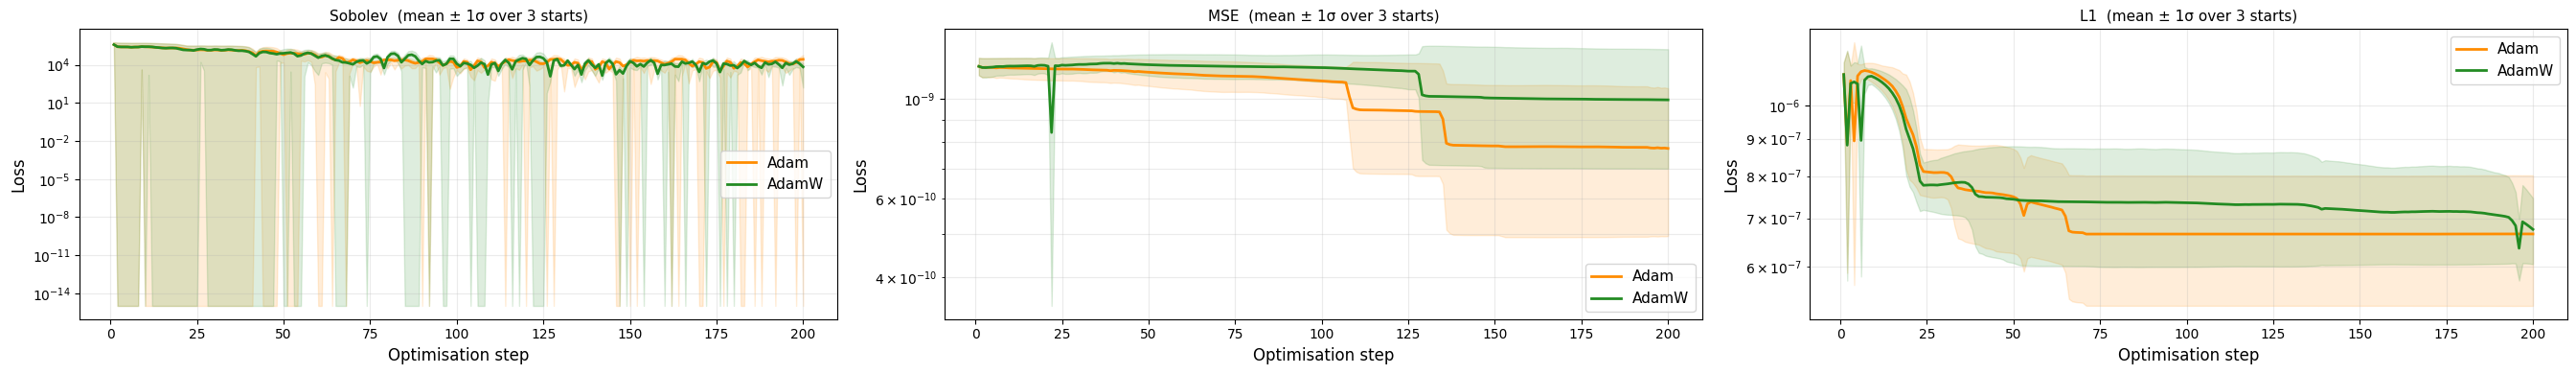

In [ ]:
steps = np.arange(1, N_STEPS + 1)

fig, axes = plt.subplots(1, len(LOSS_NAMES), figsize=(9 * len(LOSS_NAMES), 4))
if len(LOSS_NAMES) == 1:
    axes = [axes]

for ax, loss_name in zip(axes, LOSS_NAMES):
    for opt_name, trajs in all_results[loss_name].items():
        color = OPT_COLORS[opt_name]
        # entries 1..N_STEPS have valid loss (entry 0 and last are nan-loss)
        loss_matrix = np.array([[p[2] for p in traj[1:N_STEPS+1]] for traj in trajs])
        mean = np.nanmean(loss_matrix, axis=0)
        std  = np.nanstd(loss_matrix,  axis=0)
        ax.semilogy(steps, mean, color=color, lw=2, label=opt_name)
        ax.fill_between(steps,
                        np.maximum(mean - std, 1e-15),
                        mean + std,
                        color=color, alpha=0.15)
    ax.set_xlabel('Optimisation step', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'{loss_name}  (mean ± 1σ over {N_TRIES} starts)', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.25, which='both')

plt.tight_layout()
fig.savefig('../plots/optimization_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Parameter Error vs. Steps

Relative error of each parameter with respect to ground truth, mean ± 1σ.

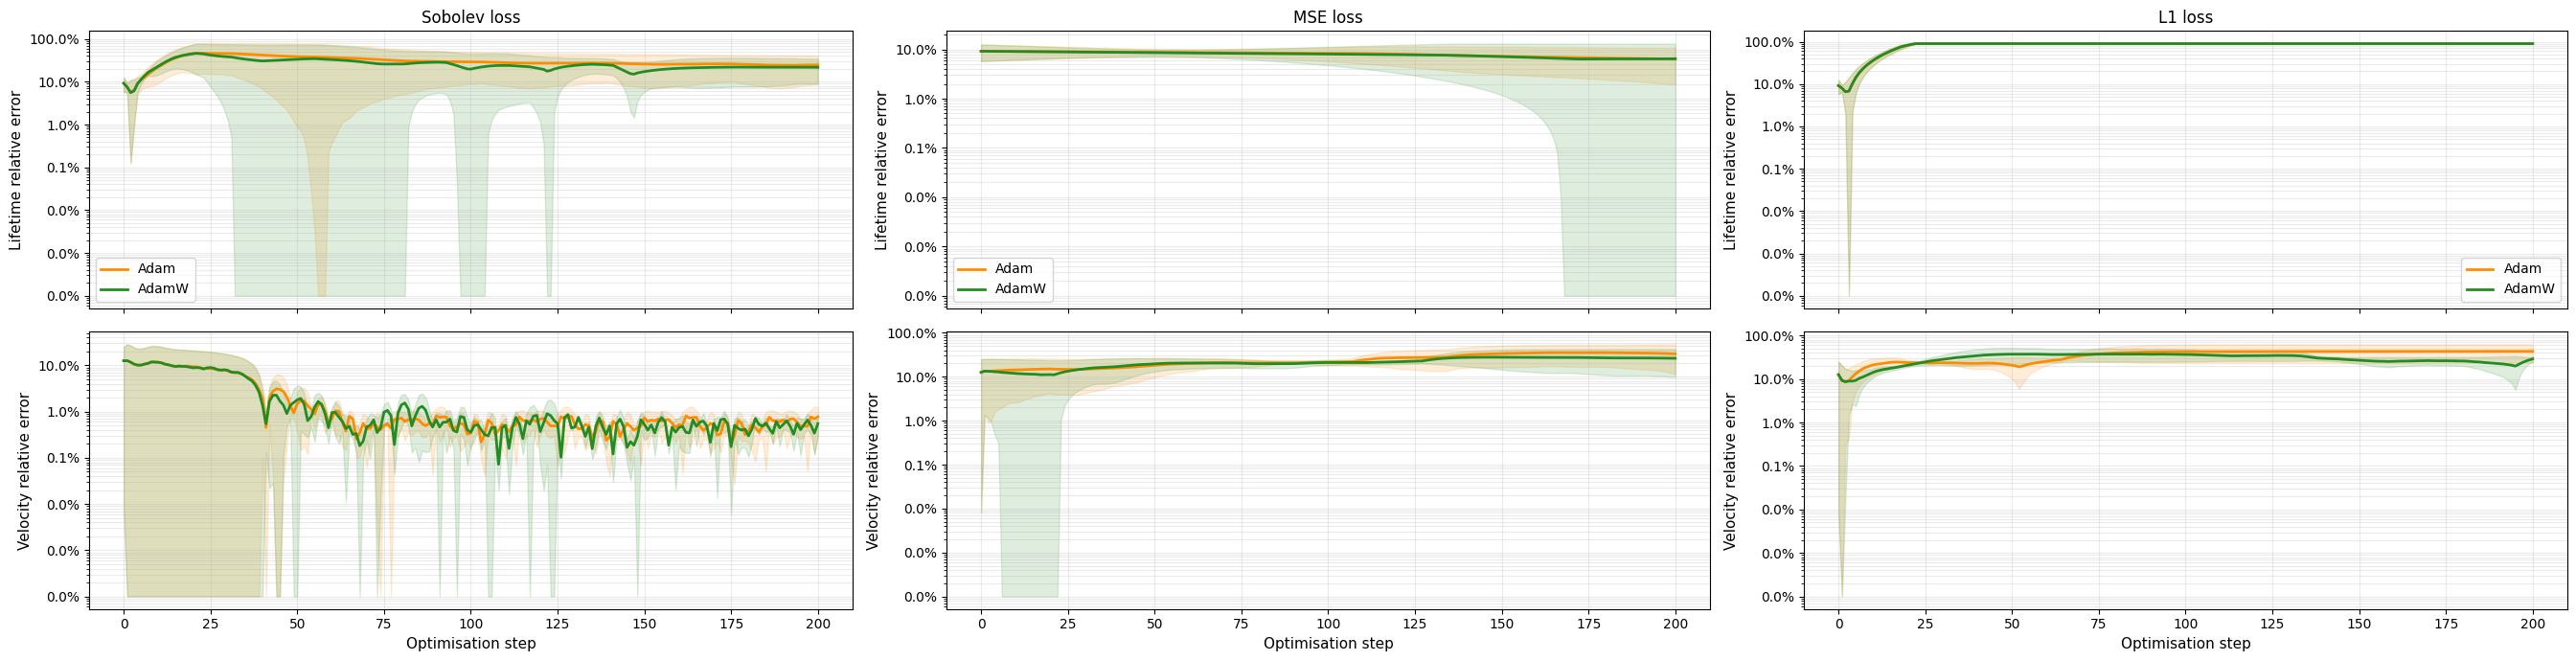

In [5]:
steps_with_start = np.arange(N_STEPS + 1)  # includes step 0

fig, axes = plt.subplots(2, len(LOSS_NAMES), figsize=(9 * len(LOSS_NAMES), 7), sharex=True)
if len(LOSS_NAMES) == 1:
    axes = axes[:, np.newaxis]

param_labels = [
    ('lifetime_us',    GT_LIFETIME_US,    0, 'Lifetime relative error'),
    ('velocity_cm_us', GT_VELOCITY_CM_US, 1, 'Velocity relative error'),
]

for col, loss_name in enumerate(LOSS_NAMES):
    for row, (pname, gt_val, pidx, ylabel) in enumerate(param_labels):
        ax = axes[row, col]
        for opt_name, trajs in all_results[loss_name].items():
            color = OPT_COLORS[opt_name]
            # entries 0..N_STEPS (skip final extra entry)
            param_matrix = np.array(
                [[p[pidx] for p in traj[:N_STEPS+1]] for traj in trajs]
            )
            rel_err = np.abs(param_matrix - gt_val) / gt_val
            mean = np.mean(rel_err, axis=0)
            std  = np.std(rel_err,  axis=0)
            ax.semilogy(steps_with_start, mean, color=color, lw=2, label=opt_name)
            ax.fill_between(steps_with_start,
                            np.maximum(mean - std, 1e-6),
                            mean + std,
                            color=color, alpha=0.15)
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
        ax.set_ylabel(ylabel, fontsize=11)
        ax.grid(True, alpha=0.25, which='both')
        if row == 0:
            ax.set_title(f'{loss_name} loss', fontsize=12)
            ax.legend(fontsize=10)
        if row == len(param_labels) - 1:
            ax.set_xlabel('Optimisation step', fontsize=11)

plt.tight_layout()
fig.savefig('../plots/optimization_param_errors.png', dpi=150, bbox_inches='tight')
plt.show()

## Gradient Norm vs. Steps

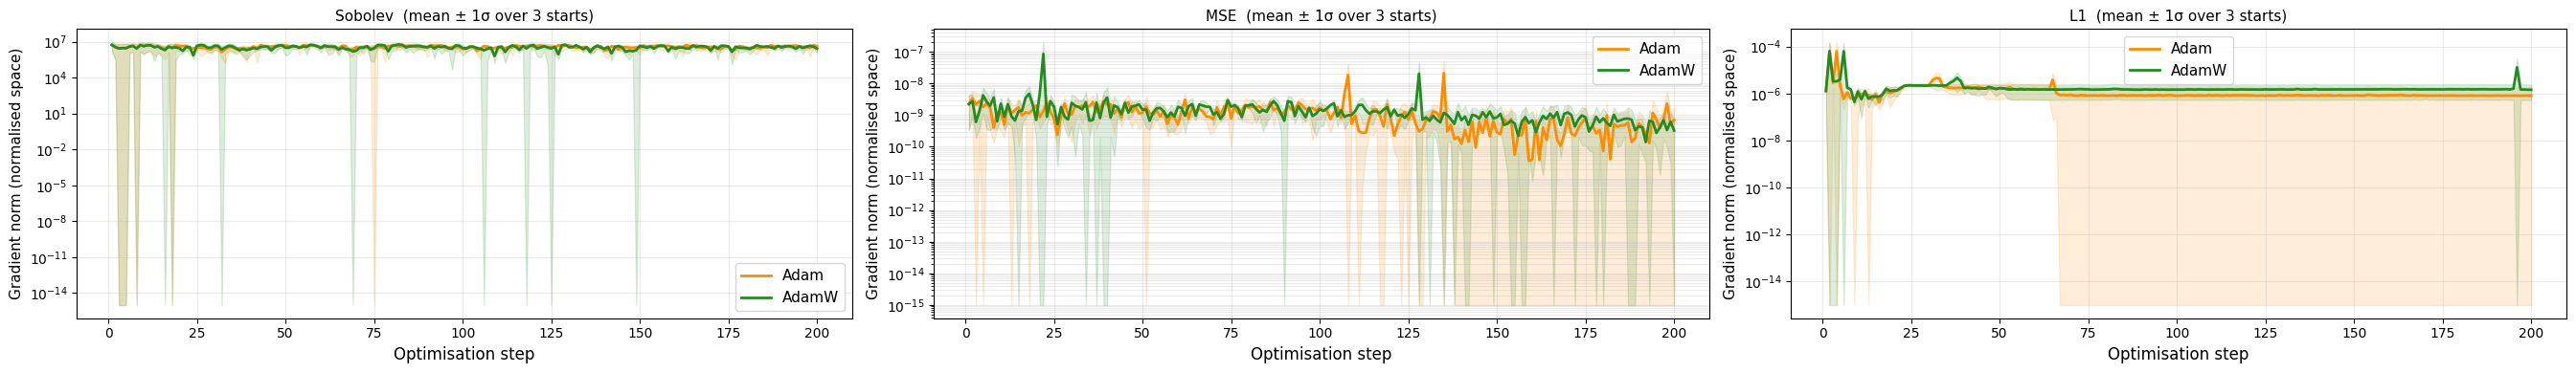

In [6]:
fig, axes = plt.subplots(1, len(LOSS_NAMES), figsize=(9 * len(LOSS_NAMES), 4))
if len(LOSS_NAMES) == 1:
    axes = [axes]

for ax, loss_name in zip(axes, LOSS_NAMES):
    for opt_name, trajs in all_results[loss_name].items():
        color = OPT_COLORS[opt_name]
        # grad_norm is at index 3; entries 1..N_STEPS
        gnorm_matrix = np.array([[p[3] for p in traj[1:N_STEPS+1]] for traj in trajs],
                                 dtype=float)
        mean = np.nanmean(gnorm_matrix, axis=0)
        std  = np.nanstd(gnorm_matrix,  axis=0)
        ax.semilogy(steps, mean, color=color, lw=2, label=opt_name)
        ax.fill_between(steps,
                        np.maximum(mean - std, 1e-15),
                        mean + std,
                        color=color, alpha=0.15)
    ax.set_xlabel('Optimisation step', fontsize=12)
    ax.set_ylabel('Gradient norm (normalised space)', fontsize=11)
    ax.set_title(f'{loss_name}  (mean ± 1σ over {N_TRIES} starts)', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.25, which='both')

plt.tight_layout()
fig.savefig('../plots/optimization_grad_norms.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Table

Final parameter errors and loss values for each loss × optimizer combination.

In [7]:
header = f"{'Loss':<10} {'Optimizer':<8}  {'lt_err %':>9}  {'vel_err %':>9}  {'final_loss':>12}"
print(header)
print('-' * len(header))

for loss_name in LOSS_NAMES:
    for opt_name, trajs in all_results[loss_name].items():
        lt_errs, vel_errs, losses = [], [], []
        for traj in trajs:
            final = traj[-1]           # last entry: (lt, vel, loss, nan, ...)
            lt_errs.append(abs(final[0] - GT_LIFETIME_US)    / GT_LIFETIME_US * 100)
            vel_errs.append(abs(final[1] - GT_VELOCITY_CM_US) / GT_VELOCITY_CM_US * 100)
            losses.append(final[2])
        print(f'{loss_name:<10} {opt_name:<8}  '
              f'{np.mean(lt_errs):>8.2f}%  '
              f'{np.mean(vel_errs):>8.2f}%  '
              f'{np.nanmean(losses):>12.4e}')

Loss       Optimizer   lt_err %  vel_err %    final_loss
--------------------------------------------------------
Sobolev    Adam         24.71%      0.78%    2.9835e+04
Sobolev    AdamW        21.72%      0.55%    1.4048e+04
MSE        Adam          6.37%     33.29%    7.7507e-10
MSE        AdamW         6.46%     26.35%    9.9482e-10
L1         Adam         90.00%     43.41%    6.6615e-07
L1         AdamW        90.00%     29.07%    6.3278e-07
